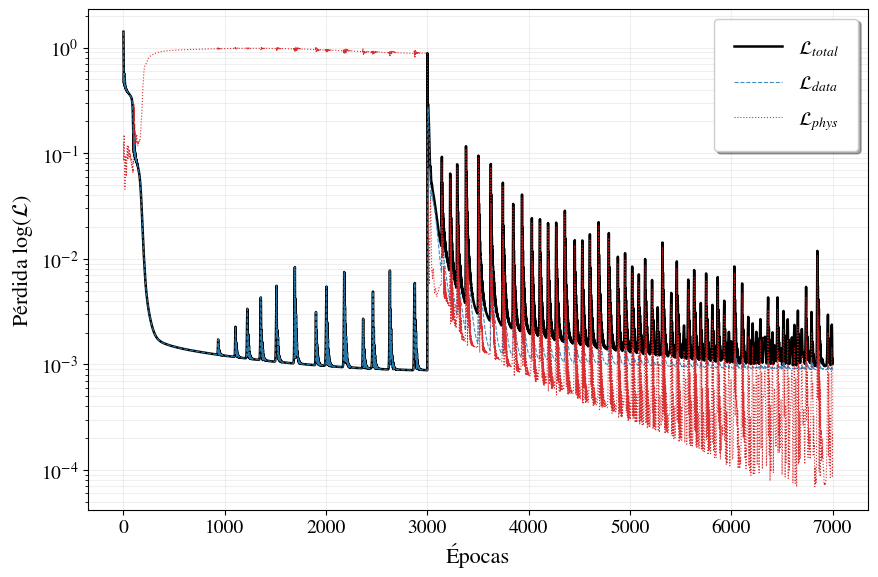

Gráfica generada: Results/Kovasznay/Kovasznay_Noisy_Convergence.png


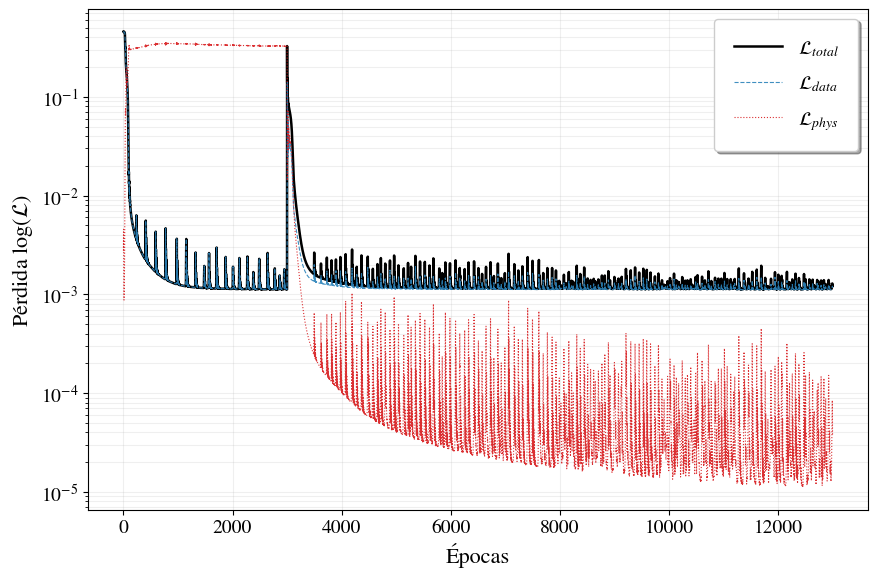

Gráfica generada: Results/TaylorGreen/TaylorGreen_Noisy_Convergence.png


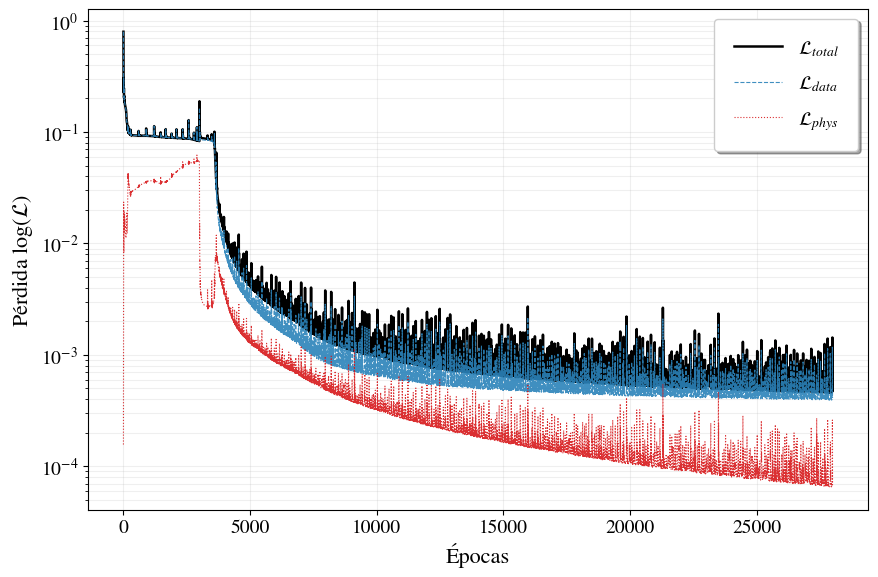

Gráfica generada: Results/Karman/VonKarman_Noisy_Convergence.png


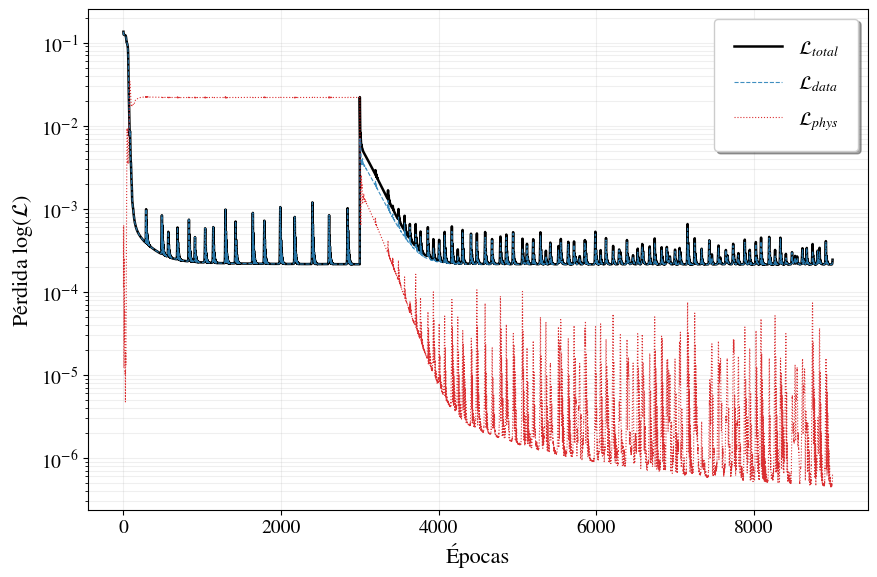

Gráfica generada: Results/Ciclonic/Ciclonic_Noisy_Convergence.png


In [5]:
import numpy as np
import matplotlib.pyplot as plt
import os

# Configuración estética
plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["STIXGeneral"],
    "mathtext.fontset": "stix",
    "font.size": 14
})

def plot_training_history(results_path, save_dir, system_name):
    """
    Grafica la convergencia de una PINN de forma dinámica.
    """
    # Verificar si el archivo existe antes de intentar cargar
    if not os.path.exists(results_path):
        print(f"⚠️ Archivo no encontrado: {results_path}")
        return

    # Cargar resultados
    data = np.load(results_path)
    
    # Extraer pérdidas
    loss_total = data['loss_total']
    loss_data = data['loss_data']
    loss_phys = data['loss_phys']
    epochs = np.arange(len(loss_total))

    # Crear figura
    plt.figure(figsize=(9, 6))

    plt.semilogy(epochs, loss_total, label=r'$\mathcal{L}_{total}$', color='black', lw=1.8)
    plt.semilogy(epochs, loss_data, label=r'$\mathcal{L}_{data}$', color="#2b83ba", linestyle='--', alpha=0.9, lw=0.8)
    plt.semilogy(epochs, loss_phys, label=r'$\mathcal{L}_{phys}$', color="#d7191c", linestyle=':', alpha=0.9, lw=0.8)

    plt.xlabel('Épocas', fontsize=16)
    plt.ylabel(r'Pérdida $\log(\mathcal{L})$', fontsize=16)
    plt.xticks(fontsize=14)
    plt.yticks(fontsize=14)
    
    plt.legend(
        fontsize=14,          # Aumentamos el tamaño de la letra
        frameon=True,         # Mantener el recuadro
        fancybox=True,        # Bordes redondeados (más elegante)
        shadow=True,          # Sombra ligera para que resalte
        borderpad=1,          # Espacio interno extra (hace el recuadro más grande)
        labelspacing=0.8,     # Espacio vertical entre las líneas
        handlelength=2.5,     # Longitud de las líneas de muestra en la leyenda
        loc='best'            # Asegura que se ubique donde menos tape datos
    )
    
    plt.grid(True, which="both", ls="-", alpha=0.2)
    plt.tight_layout()
    
    save_path = os.path.join(save_dir, f'{system_name}_Noisy_Convergence.png')
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show() # Importante: cerrar para liberar memoria
    print(f"Gráfica generada: {save_path}")

if __name__ == "__main__":
    # Definimos la lista de sistemas para procesar
    # Formato: (ruta_resultados, carpeta_guardado, nombre_sistema)
    configs = [
        ('Results/Kovasznay/kovasznay_results.npz', 'Results/Kovasznay', 'Kovasznay'),
        ('Results/TaylorGreen/taylor_green_results.npz', 'Results/TaylorGreen', 'TaylorGreen'),
        ('Results/Karman/cylinder_results.npz', 'Results/Karman', 'VonKarman'),
        ('Results/Ciclonic/ciclonic_results.npz', 'Results/Ciclonic', 'Ciclonic')
    ]
    
    for path, directory, name in configs:
        plot_training_history(path, directory, name)